In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y dataset')

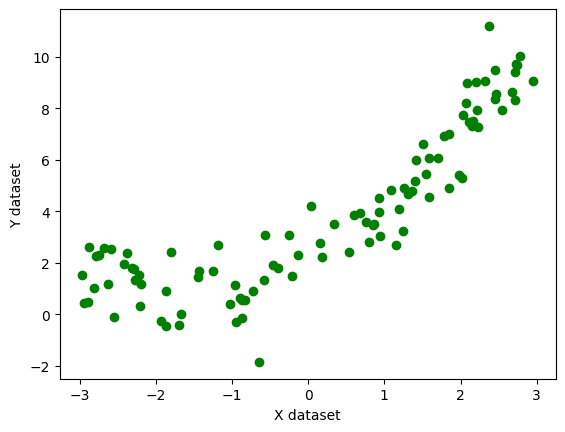

In [12]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
regression_1=LinearRegression(n_jobs=-1)
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_predict=regression_1.predict(X_test)

In [17]:
print("Intercept: ",regression_1.intercept_)
print("Coef Value: ",regression_1.coef_)

## Performance Metrics
print("MSE: ",mean_squared_error(y_test,y_predict))
print("MAE: ",mean_absolute_error(y_test,y_predict))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_predict)))
print("R-Square: ",r2_score(y_test,y_predict))
print("Adjusted R-Square: ",(1 -(1-r2_score(y_test,y_predict))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)))

Intercept:  [3.65340424]
Coef Value:  [[1.4637641]]
MSE:  2.03551439556159
MAE:  1.2912521101142689
RMSE:  1.4267145459276673
R-Square:  0.751418367258936
Adjusted R-Square:  0.7376082765510991


Text(0, 0.5, 'Y')

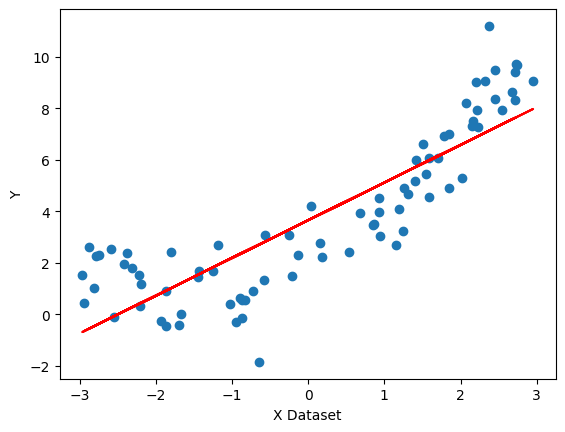

In [18]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [19]:
#Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures


In [20]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [21]:
X_train_poly

array([[ 1.00000000e+00,  1.19026120e+00,  1.41672172e+00,
         1.68626889e+00],
       [ 1.00000000e+00, -2.42093060e+00,  5.86090496e+00,
        -1.41888442e+01],
       [ 1.00000000e+00, -8.62864897e-01,  7.44535830e-01,
        -6.42433833e-01],
       [ 1.00000000e+00,  2.44717544e+00,  5.98866761e+00,
         1.46553203e+01],
       [ 1.00000000e+00,  2.53838886e+00,  6.44341799e+00,
         1.63559004e+01],
       [ 1.00000000e+00,  1.15667815e+00,  1.33790434e+00,
         1.54752472e+00],
       [ 1.00000000e+00,  2.21184893e+00,  4.89227571e+00,
         1.08209748e+01],
       [ 1.00000000e+00,  1.54304109e+00,  2.38097582e+00,
         3.67394353e+00],
       [ 1.00000000e+00,  2.45430615e+00,  6.02361870e+00,
         1.47838045e+01],
       [ 1.00000000e+00, -5.61903217e-01,  3.15735225e-01,
        -1.77412639e-01],
       [ 1.00000000e+00,  2.32219027e+00,  5.39256765e+00,
         1.25225681e+01],
       [ 1.00000000e+00, -7.24288766e-01,  5.24594217e-01,
      

In [22]:
X_test_poly

array([[  1.        ,  -0.39713686,   0.15771769,  -0.06263551],
       [  1.        ,  -0.45584872,   0.20779806,  -0.09472448],
       [  1.        ,  -0.95912161,   0.91991427,  -0.88230966],
       [  1.        ,  -2.63203885,   6.92762852, -18.23378744],
       [  1.        ,   1.0856944 ,   1.17873232,   1.27974307],
       [  1.        ,   0.33894247,   0.114882  ,   0.03893839],
       [  1.        ,  -2.67899798,   7.17703016, -19.22724929],
       [  1.        ,   2.03175277,   4.12801933,   8.38711471],
       [  1.        ,   0.59947614,   0.35937164,   0.21543473],
       [  1.        ,  -2.2664864 ,   5.1369606 , -11.64285133],
       [  1.        ,   0.79894171,   0.63830786,   0.50997078],
       [  1.        ,  -2.8942287 ,   8.37655977, -24.24367972],
       [  1.        ,   2.78121525,   7.73515829,  21.51314024],
       [  1.        ,   0.7654106 ,   0.58585339,   0.4484184 ],
       [  1.        ,   2.46691336,   6.08566153,  15.01279972],
       [  1.        ,   2

In [23]:
regression=LinearRegression()
regression.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_predict_poly=regression.predict(X_test_poly)

In [25]:
print("Intercept: ",regression.intercept_)
print("Coef Value: ",regression.coef_)

## Performance Metrics
print("MSE: ",mean_squared_error(y_test,y_predict_poly))
print("MAE: ",mean_absolute_error(y_test,y_predict_poly))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_predict_poly)))
print("R-Square: ",r2_score(y_test,y_predict_poly))
print("Adjusted R-Square: ",(1 -(1-r2_score(y_test,y_predict_poly))*(len(y_test)-1)/(len(y_test)-X_test_poly.shape[1]-1)))

Intercept:  [2.03239889]
Coef Value:  [[ 0.          1.6134052   0.47038713 -0.02366648]]
MSE:  0.6123522421196715
MAE:  0.6225063354592141
RMSE:  0.7825293873840595
R-Square:  0.925218155916425
Adjusted R-Square:  0.9052763308274716


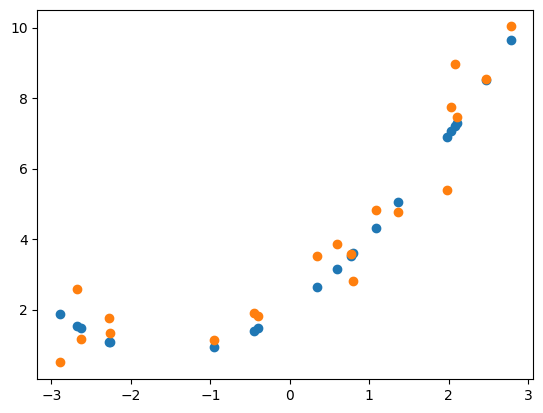

In [30]:
plt.scatter(X_test,y_predict_poly)
plt.scatter(X_test,y_test)

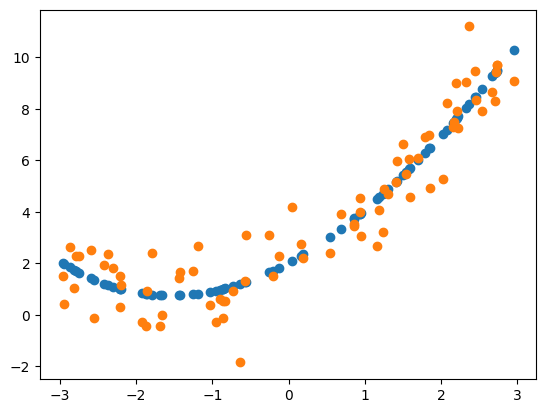

In [31]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [51]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

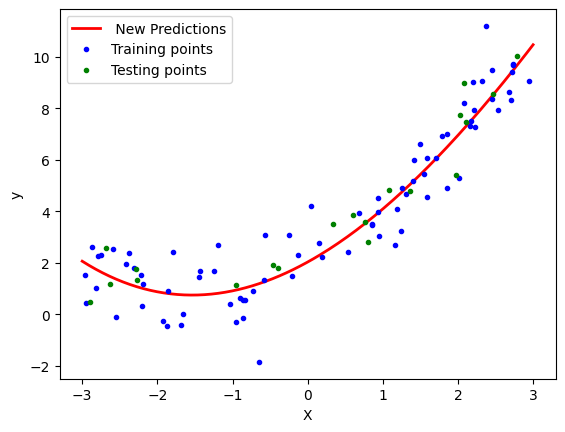

In [52]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [55]:
print("Intercept: ",regression.intercept_)
print("Coef Value: ",regression.coef_)
  

Intercept:  [2.03239889]
Coef Value:  [[ 0.          1.6134052   0.47038713 -0.02366648]]


## Pipeline Concepts 

In [36]:
from sklearn.pipeline import Pipeline

In [58]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="New Predictions with Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.",label='Training points')
    plt.plot(X_test, y_test, "g.",label='Testing points')
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

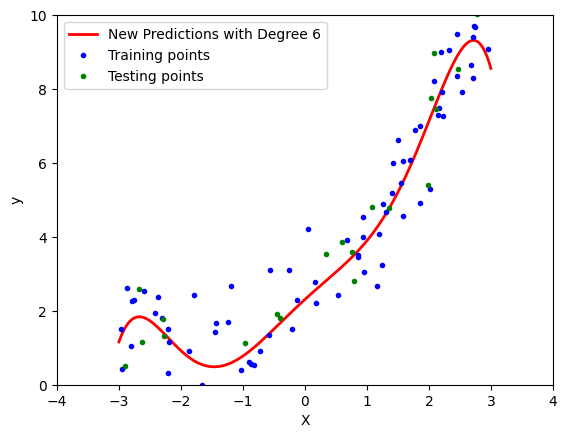

In [59]:
poly_regression(6)